en esta parte se realizara la limpieza y transformaciond e los datos para preparlos antes del entrenamiento 

In [91]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler


import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
train = pd.read_csv("00.data/raw/train.csv")
test = pd.read_csv("00.data/raw/test.csv")

In [93]:
train_original = train.copy()

en la parte anterior vimos como algunas viviendas con superficies extremadamente grandes tienen un precio bajo, esto pordia afectar negativamente al modelo asi que se eliminan del dataset

In [94]:
train = train[
    ~((train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000))
]

aplicamos la transformacion logaritmica ya que la variable objetivo estaba sesgada positivamente y se aplica transformacion logaritmica para reducir la asimetria y mejorar el comportamiento del modelo

In [95]:
train["SalePrice_log"] = np.log1p(train["SalePrice"])

separamos variables predictoras y variable objetivo 

In [96]:
X = train.drop(["SalePrice", "SalePrice_log"], axis=1)

y = train["SalePrice_log"]

Primero se guardan los valores de la columna id para poder utilizarlos más adelante al crear el archivo final de predicciones.

Después, la columna id se elimina de los datasets porque solo sirve como identificador y no aporta información útil para predecir el precio de las viviendas.

In [97]:
train_ids = X["Id"]
test_ids = test["Id"]

In [98]:
X = X.drop("Id", axis=1)
test = test.drop("Id", axis=1)

ahora pasamos con el tratamiento de nulos

In [99]:
missing = X.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False).head(20)

PoolQC          1452
MiscFeature     1404
Alley           1367
Fence           1177
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

en algunas columnas los datos nulos no representan un error, represetnan que no tienen asi que creamos una nueva etiqueta llamada none para representar que estas casas no tienen esas caracteristicas 

In [100]:
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

In [101]:
for col in none_cols:
    X[col] = X[col].fillna("None")
    test[col] = test[col].fillna("None")

In [102]:
numeric_cols = X.select_dtypes(include=np.number).columns

para las variables numericas con nulos los relleno con la mediana para poder evitar los outliers y los valores extremos

In [103]:
for col in numeric_cols:
    
    X[col] = X[col].fillna(X[col].median())
    
    test[col] = test[col].fillna(test[col].median())

despues las variables categoricas se rellenan con la moda, para que sea el valor mas frecuente.

In [104]:
cat_cols = X.select_dtypes(include="object").columns

C:\Users\Usuario\AppData\Local\Temp\ipykernel_8892\1350123441.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


In [105]:
for col in cat_cols:
    
    X[col] = X[col].fillna(X[col].mode()[0])
    
    test[col] = test[col].fillna(test[col].mode()[0])

In [106]:
print(X.isnull().sum().sum())

print(test.isnull().sum().sum())

0
0


ahora creamos variables nuevas a partir de informacion ya existente: 
vemos la antiguedad de la casa de manera mas clara aunque tampoco seria 100% necesario
en total bathrooms creamos la variable que crea todos los baños de la casa en una sola caracteristica. 
tambien creo la variable de total square feet que es la suma de todas las superficies de la casa 

In [107]:
X["HouseAge"] = 2025 - X["YearBuilt"]

test["HouseAge"] = 2025 - test["YearBuilt"]

In [ ]:
X["TotalBathrooms"] = (
    
    X["FullBath"] +
    
    (0.5 * X["HalfBath"]) +
    
    X["BsmtFullBath"] +
    
    (0.5 * X["BsmtHalfBath"])
)


In [121]:
test["TotalBathrooms"] = (
    
    test["FullBath"] +
    
    (0.5 * test["HalfBath"]) +
    
    test["BsmtFullBath"] +
    
    (0.5 * test["BsmtHalfBath"])
)

In [110]:
X["TotalSF"] = (
    
    X["TotalBsmtSF"] +
    
    X["1stFlrSF"] +
    
    X["2ndFlrSF"]
)

In [111]:
test["TotalSF"] = (
    
    test["TotalBsmtSF"] +
    
    test["1stFlrSF"] +
    
    test["2ndFlrSF"]
)

In [122]:
X[[
    "HouseAge",
    "TotalBathrooms",
    "TotalSF"
]].head()

,HouseAge,TotalBathrooms,TotalSF
0,22,3.5,2566
1,49,2.5,2524
2,24,3.5,2706
3,110,2.0,2473
4,25,3.5,3343


las variables categoricas se transforman en numericas usando one hot encoding para que los modelos de ML puedan trabajar correctamente 

In [112]:
X = pd.get_dummies(X, drop_first=True)

test = pd.get_dummies(test, drop_first=True)

se alinean los datasets para que tengan las mismas columnas 

In [113]:
X, test = X.align(
    test,
    join="left",
    axis=1,
    fill_value=0
)

Se aplica estandarización a las variables numéricas para que todas tengan una escala similar

In [114]:
scaler = StandardScaler()

el escalador se ajusta unsando los datos de entrenamiento y se aplica tanto a los datos de entrenamiento como a los de test 

In [115]:
X_scaled = scaler.fit_transform(X)

test_scaled = scaler.transform(test)

In [116]:
print(X_scaled.shape)

print(test_scaled.shape)

(1458, 260)
(1459, 260)


hacemos un pequeño analisis  para ver como cambian las cosas antes y despues del preprocesing de los datos antes del ML 

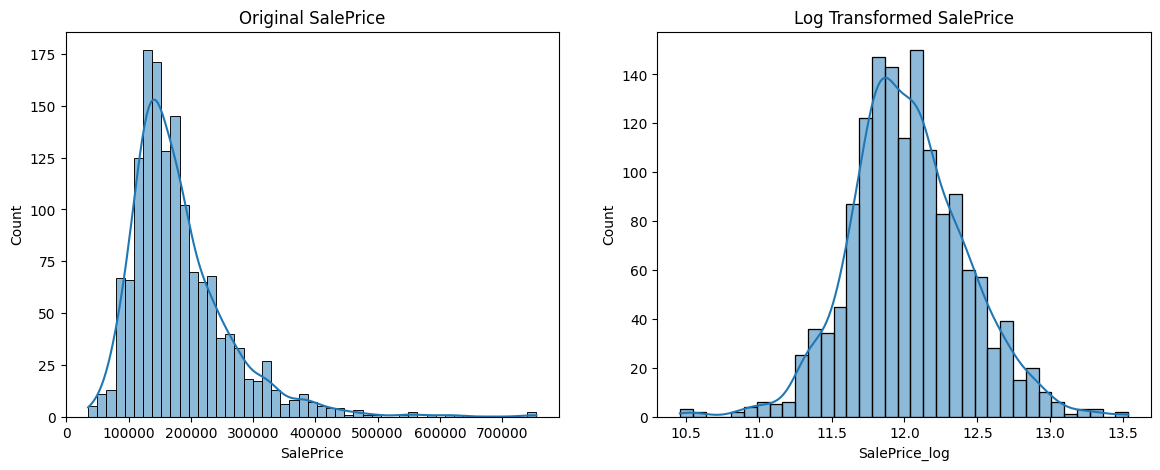

In [117]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(train["SalePrice"], kde=True, ax=ax[0])
ax[0].set_title("Original SalePrice")

sns.histplot(y, kde=True, ax=ax[1])
ax[1].set_title("Log Transformed SalePrice")

plt.show()

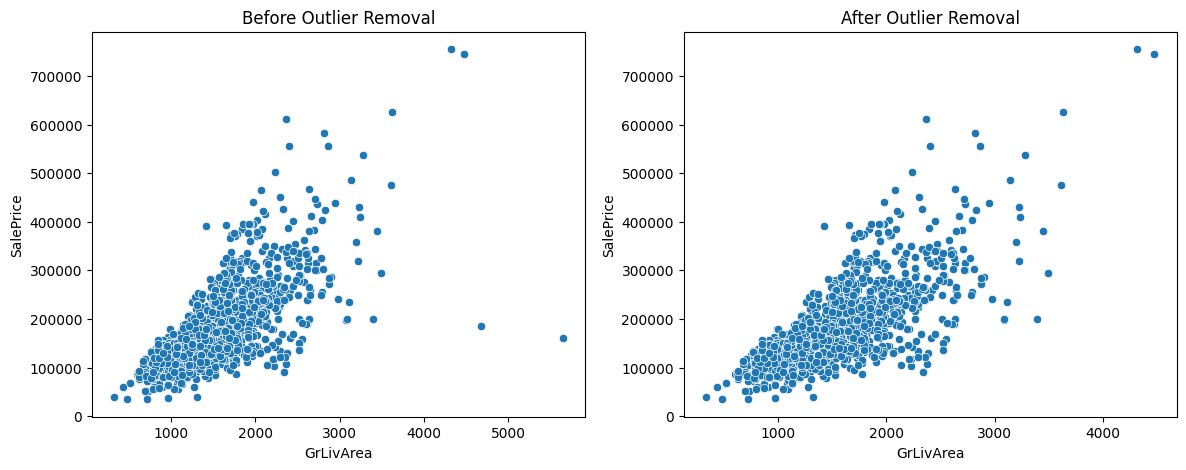

In [118]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(
    x=train_original["GrLivArea"],
    y=train_original["SalePrice"],
    ax=ax[0]
)

ax[0].set_title("Before Outlier Removal")

sns.scatterplot(
    x=train["GrLivArea"],
    y=train["SalePrice"],
    ax=ax[1]
)

ax[1].set_title("After Outlier Removal")

plt.show()

aunque parezca igual, las observaciones si que pueden cambiar el modelo 

In [119]:
print("Missing values before preprocessing:")
print(train_original.isnull().sum().sum())

print()

print("Missing values after preprocessing:")
print(X.isnull().sum().sum())

Missing values before preprocessing:
7829

Missing values after preprocessing:
0


una ves acabada la transformacion de los datos, lis datasets transformados se guardan en csv y estos se utilizaran posteriormente en la fase de de entrenamiento y evaluacion de modelos. 

In [120]:
pd.DataFrame(X_scaled).to_csv(
    "00.data/cleaned/X_scaled.csv",
    index=False
)

pd.DataFrame(test_scaled).to_csv(
    "00.data/cleaned/test_scaled.csv",
    index=False
)

y.to_csv(
    "00.data/cleaned/y.csv",
    index=False
)